In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

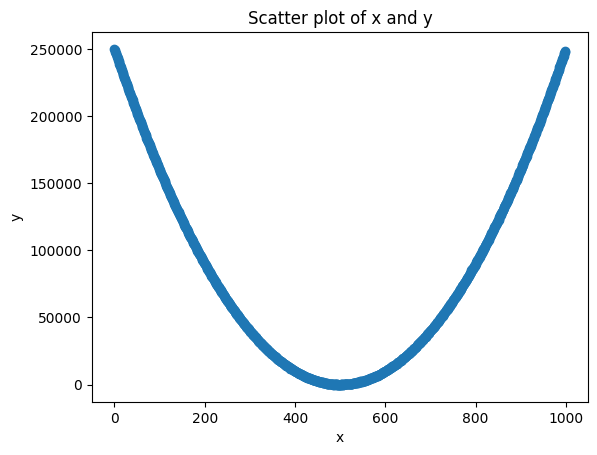

In [2]:
x = list(range(1000))
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]
df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

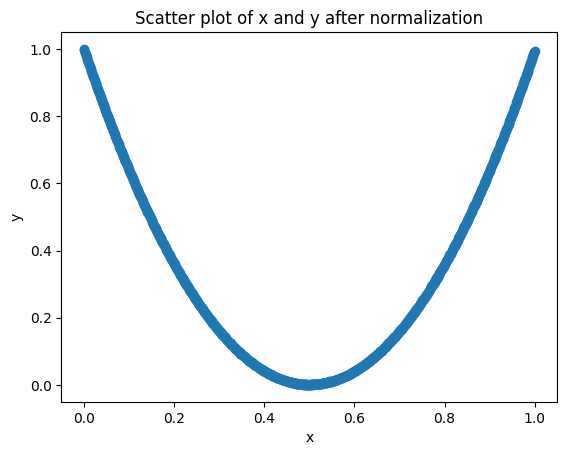

In [3]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [4]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [5]:
import keras

In [22]:
input_shape = (2,)
#encoder = keras.models.Sequential([keras.layers.Dense(2)])
#decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

stacked_encoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
        ])

stacked_decoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu", input_shape=[1]),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(input_shape[0], activation="linear"),
        ])



autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        stacked_encoder, 
        stacked_decoder
])
autoencoder.summary()


c:\Users\marco\Dropbox\Documenti\DIDATTICA\data science and management (RE)\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 1)              │         2,751 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 2)              │         2,752 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,503 (21.50 KB)

 Trainable params: 5,503 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
autoencoder.compile(loss="mse", optimizer='adam')
history = autoencoder.fit(x_train, x_train, epochs=150)
codings = stacked_encoder.predict(x_train)

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0172   
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0166 
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0155 
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0156 
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0154 
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 
Epoch 9/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0144 
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0139 
Epoch 11/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0137 
Epoch 12/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0134 
Epoch 13/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131 
Epoch 14/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0130 
Epoch 15/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - l

In [25]:
T = codings
T.shape

(1000, 1)

In [28]:
T

array([[0.5283745 ],
       [0.5276362 ],
       [0.52685493],
       [0.5259758 ],
       [0.52509654],
       [0.5242159 ],
       [0.5233227 ],
       [0.522431  ],
       [0.5215436 ],
       [0.52065575],
       [0.51977605],
       [0.51889616],
       [0.5180174 ],
       [0.5171354 ],
       [0.5162519 ],
       [0.51538426],
       [0.514503  ],
       [0.51364905],
       [0.5127729 ],
       [0.51191735],
       [0.51104116],
       [0.5102394 ],
       [0.50946045],
       [0.50867975],
       [0.507895  ],
       [0.50711954],
       [0.5063423 ],
       [0.50558376],
       [0.5048082 ],
       [0.5040305 ],
       [0.5032685 ],
       [0.5025103 ],
       [0.50175166],
       [0.5009815 ],
       [0.5002296 ],
       [0.4994885 ],
       [0.49894568],
       [0.49848357],
       [0.4980083 ],
       [0.49755234],
       [0.49708745],
       [0.4966226 ],
       [0.49617755],
       [0.4956182 ],
       [0.49495074],
       [0.4946033 ],
       [0.49425998],
       [0.493

In [26]:
newdf = stacked_decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[0.01703973, 0.9993782 ],
       [0.01688098, 0.9963778 ],
       [0.01680895, 0.992941  ],
       ...,
       [1.0036578 , 0.9728175 ],
       [1.0043349 , 0.97529685],
       [1.0043188 , 0.9753344 ]], shape=(1000, 2), dtype=float32)

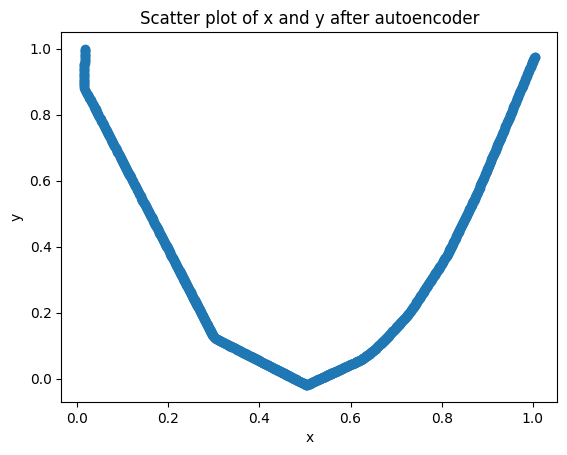

In [27]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()